In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

# Data Understanding


In [4]:
data=pd.read_csv("../datasets/PJME_hourly.csv")

View the rows and columns in the datasets

In [5]:
data.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [6]:
data.tail()

,Datetime,PJME_MW
145361,2018-01-01 20:00:00,44284.0
145362,2018-01-01 21:00:00,43751.0
145363,2018-01-01 22:00:00,42402.0
145364,2018-01-01 23:00:00,40164.0
145365,2018-01-02 00:00:00,38608.0


In [7]:
data.shape

(145366, 2)

In [8]:
data.dtypes

Datetime        str
PJME_MW     float64
dtype: object

In [9]:
data.columns

Index(['Datetime', 'PJME_MW'], dtype='str')

In [10]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  str    
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), str(1)
memory usage: 2.2 MB


# Missing Values Check

In [11]:
missing_value=data.isnull().sum().sort_values(ascending=False)
print("Missing Values:",missing_value)

Missing Values: Datetime    0
PJME_MW     0
dtype: int64


# Convert Datetime column and set as index

In [12]:
data['Datetime']=pd.to_datetime(data['Datetime'])

In [13]:
data.dtypes

Datetime    datetime64[us]
PJME_MW            float64
dtype: object

In [14]:
data.set_index('Datetime',inplace=True)

In [15]:
data.head()

,PJME_MW
Datetime,
2002-12-31 01:00:00,26498.0
2002-12-31 02:00:00,25147.0
2002-12-31 03:00:00,24574.0
2002-12-31 04:00:00,24393.0
2002-12-31 05:00:00,24860.0


In [16]:
data.index

DatetimeIndex(['2002-12-31 01:00:00', '2002-12-31 02:00:00',
               '2002-12-31 03:00:00', '2002-12-31 04:00:00',
               '2002-12-31 05:00:00', '2002-12-31 06:00:00',
               '2002-12-31 07:00:00', '2002-12-31 08:00:00',
               '2002-12-31 09:00:00', '2002-12-31 10:00:00',
               ...
               '2018-01-01 15:00:00', '2018-01-01 16:00:00',
               '2018-01-01 17:00:00', '2018-01-01 18:00:00',
               '2018-01-01 19:00:00', '2018-01-01 20:00:00',
               '2018-01-01 21:00:00', '2018-01-01 22:00:00',
               '2018-01-01 23:00:00', '2018-01-02 00:00:00'],
              dtype='datetime64[us]', name='Datetime', length=145366, freq=None)

# Analyze timestamps and time intervals

In [17]:
print("Start Date:",data.index.min())
print("End Date:",data.index.max())

Start Date: 2002-01-01 01:00:00
End Date: 2018-08-03 00:00:00


In [18]:
print(" Total Duration:",data.index.max()-data.index.min())

 Total Duration: 6057 days 23:00:00


In [46]:
data = data.sort_index()

In [47]:
time_difference=data.index.to_series().diff()

In [48]:
time_difference.value_counts().head()

Datetime
0 days 01:00:00    145331
0 days 02:00:00        30
0 days 00:00:00         4
Name: count, dtype: int64

# Missing value percentage

In [21]:
mis_per=(missing_value/len(data))*100
print("missing percentage:",mis_per)

missing percentage: Datetime    0.0
PJME_MW     0.0
dtype: float64


# Duplicate values Check

In [24]:
dup_data=data.duplicated().sum()
print("Duplicate Rows:",dup_data)

Duplicate Rows: 116925


In [25]:
dup_timestamps=data.index.duplicated().sum()
print("Duplicate Timestamps:",dup_timestamps)

Duplicate Timestamps: 4


# Statistics

In [26]:
round(data.describe())

,PJME_MW
count,145366.0
mean,32080.0
std,6464.0
min,14544.0
25%,27573.0
50%,31421.0
75%,35650.0
max,62009.0


# Analyze consumption trends

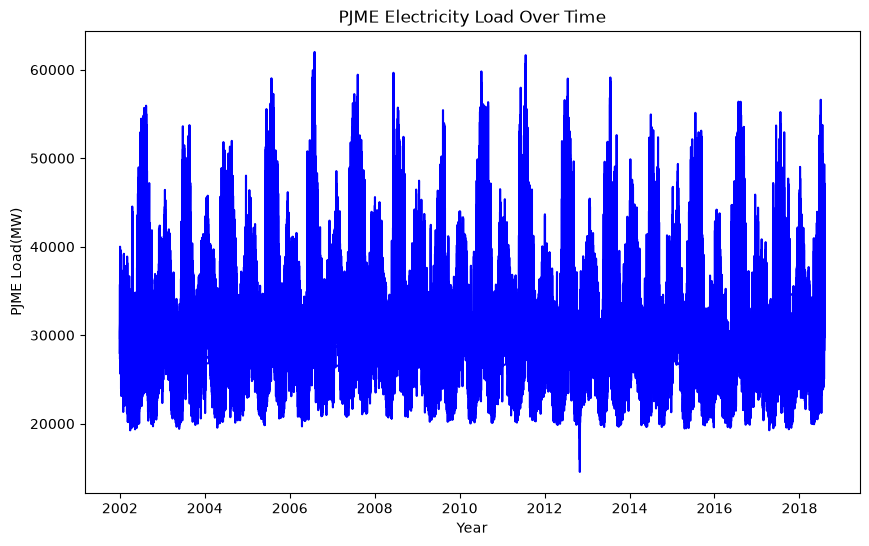

In [27]:
plt.figure(figsize=(10,6))
plt.plot(data.index,data['PJME_MW'],color='blue')
plt.title("PJME Electricity Load Over Time")
plt.xlabel("Year")
plt.ylabel("PJME Load(MW)")
plt.show()

# Daily consumption pattern

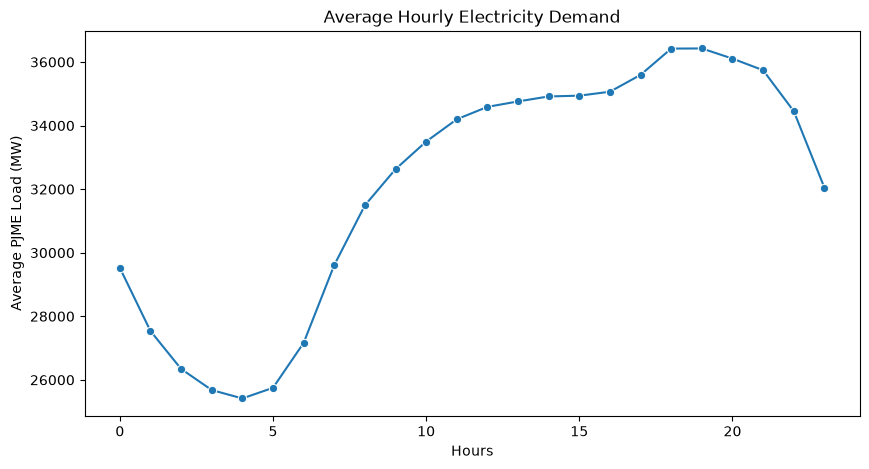

In [28]:
hourly_pattern=data.groupby(data.index.hour)['PJME_MW'].mean()
plt.figure(figsize=(10,5))
sns.lineplot(x=hourly_pattern.index, y=hourly_pattern.values, marker='o') 
plt.title('Average Hourly Electricity Demand') 
plt.xlabel('Hours') 
plt.ylabel('Average PJME Load (MW)') 
plt.show()

# Weekly consumption pattern

In [29]:
weekday_pattern=data.groupby(data.index.day_name())['PJME_MW'].mean()

In [30]:
#arrange monday to sunday
week_order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

In [31]:
weekday_pattern=weekday_pattern.reindex(week_order)
weekday_pattern

Datetime
Monday       32672.028420
Tuesday      33272.265746
Wednesday    33261.497498
Thursday     33085.857727
Friday       32688.097688
Saturday     30162.880588
Sunday       29411.869930
Name: PJME_MW, dtype: float64

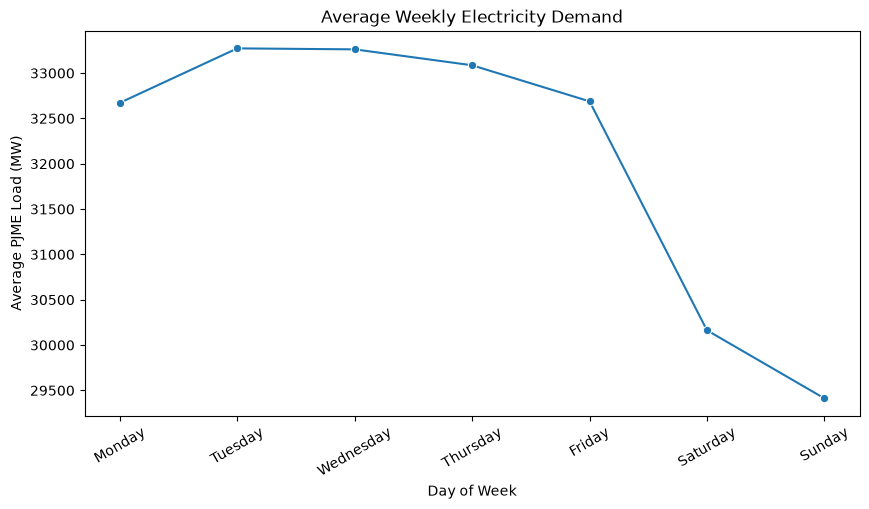

In [33]:
plt.figure(figsize=(10,5)) 
sns.lineplot(x=weekday_pattern.index, y=weekday_pattern.values, marker='o') 
plt.title('Average Weekly Electricity Demand') 
plt.xlabel('Day of Week') 
plt.ylabel('Average PJME Load (MW)') 
plt.xticks(rotation=30) 
plt.show()

# Monthly consumption trend

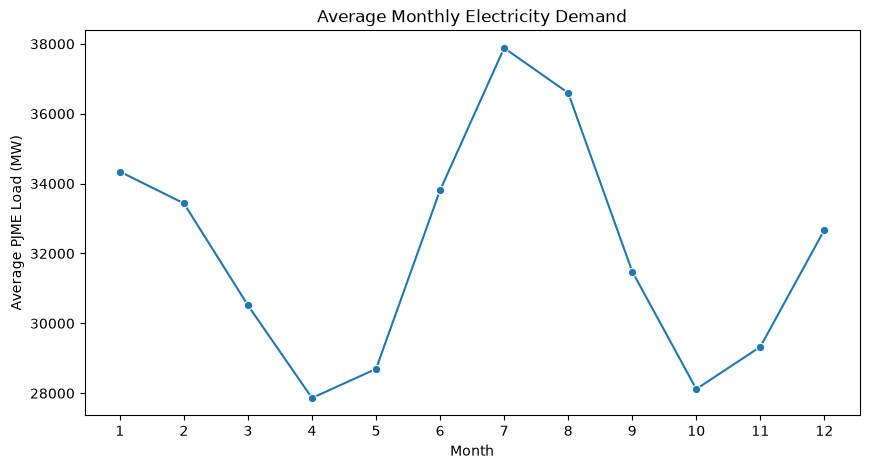

In [38]:
monthly_pattern = data.groupby(data.index.month)['PJME_MW'].mean() 
plt.figure(figsize=(10,5)) 
sns.lineplot(x=monthly_pattern.index, y=monthly_pattern.values, marker='o') 
plt.title('Average Monthly Electricity Demand') 
plt.xlabel('Month') 
plt.ylabel('Average PJME Load (MW)') 
plt.xticks(range(1,13)) 
plt.show()

# Distribution plot

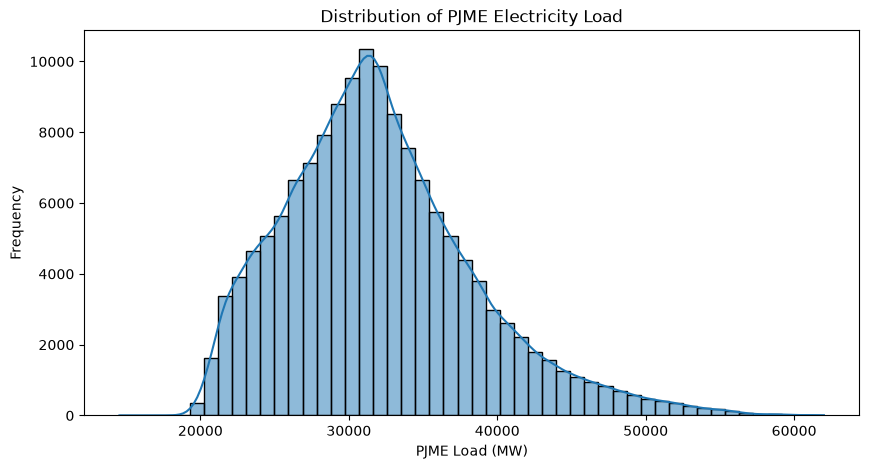

In [41]:
plt.figure(figsize=(10,5))
sns.histplot(data['PJME_MW'], bins=50, kde=True)
plt.title('Distribution of PJME Electricity Load') 
plt.xlabel('PJME Load (MW)') 
plt.ylabel('Frequency') 
plt.show()

# Seasonal decomposition

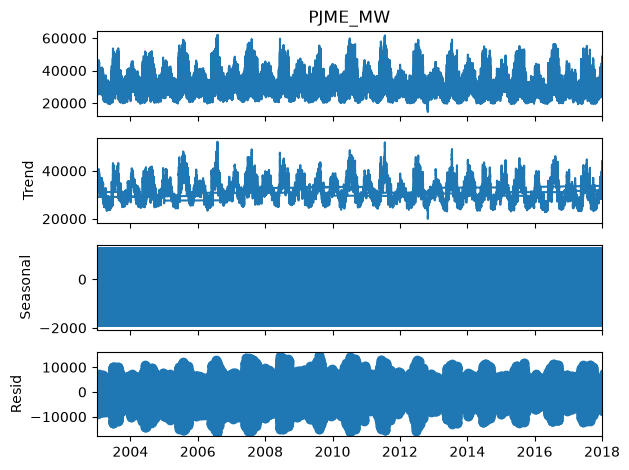

In [42]:
decomposition=seasonal_decompose(data['PJME_MW'].dropna(),model='additive',period=24)
decomposition.plot()
plt.show()

# Identify abnormal consumption periods

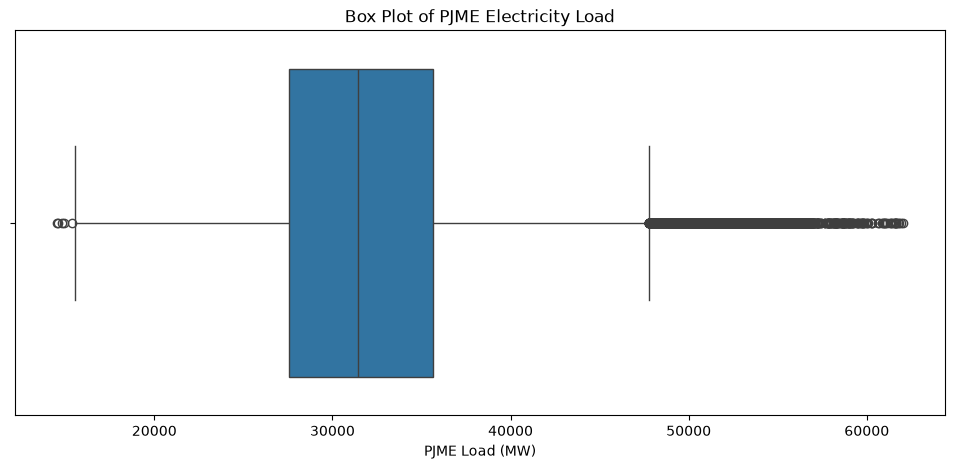

In [43]:
plt.figure(figsize=(12,5)) 
sns.boxplot(x=data['PJME_MW']) 
plt.title('Box Plot of PJME Electricity Load') 
plt.xlabel('PJME Load (MW)') 
plt.show() 

In [45]:
# Top abnormal values 
data['PJME_MW'].sort_values(ascending=False).head(20)

Datetime
2006-08-02 17:00:00    62009.0
2006-08-02 16:00:00    61909.0
2006-08-03 17:00:00    61796.0
2006-08-03 16:00:00    61770.0
2011-07-22 15:00:00    61646.0
2006-08-01 17:00:00    61643.0
2006-08-02 15:00:00    61641.0
2006-08-02 18:00:00    61610.0
2011-07-22 16:00:00    61608.0
2011-07-22 14:00:00    61532.0
2006-08-03 15:00:00    61440.0
2006-08-01 16:00:00    61366.0
2011-07-22 17:00:00    61312.0
2006-08-01 18:00:00    61155.0
2006-08-02 14:00:00    61008.0
2006-08-01 15:00:00    61004.0
2006-08-03 18:00:00    60971.0
2011-07-22 13:00:00    60904.0
2006-08-03 14:00:00    60835.0
2011-07-21 17:00:00    60689.0
Name: PJME_MW, dtype: float64